<a href="https://colab.research.google.com/github/malanda20/Data-Science/blob/main/SVM_SVR_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ============================================================
# Régression supervisée avec SVM (SVR) – Pipeline complet
# Jeu de données : Logement en Californie (scikit-learn)
# - Division des ensembles d'entraînement, de validation et de test
# - Mise à l'échelle au sein du pipeline
# - Validation croisée (GridSearchCV) sur TRAIN
# - Performance finale sur un ensemble de test inconnu
# ============================================================

In [ ]:
import numpy as np
import pandas as pd


from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


import matplotlib.pyplot as plt

# ---------------------------------------
# 1. Load real regression dataset
# ---------------------------------------

In [ ]:
california = fetch_california_housing(as_frame=True)


X = california.data # features (DataFrame)
y = california.target # median house value (continuous)


print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)
print("Feature names:", list(X.columns), "\n")


Feature matrix shape: (20640, 8)
Target vector shape: (20640,)
Feature names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude'] 



In [ ]:
print("First 5 rows:")
print(X.head(), "\n")
print("Target (first 5):")
print(y.head(), "\n")



First 5 rows:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25   

Target (first 5):
0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: MedHouseVal, dtype: float64 



# ---------------------------------------------------
# 2. Split into Train, Validation, and Test sets
#    We'll do: 60% train, 20% val, 20% test
# ---------------------------------------------------

In [ ]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
 X, y,
 test_size=0.2,
 random_state=42
)

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
X_train_val, y_train_val,
test_size=0.25, # 25% of 80% -> 20% of total
random_state=42
)


print("Train shape:     ", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:      ", X_test.shape, "\n")





Train shape:      (12384, 8)
Validation shape: (4128, 8)
Test shape:       (4128, 8) 



# ---------------------------------------------------
# 3. Build a Pipeline: Scaling + SVR
# ---------------------------------------------------


In [ ]:
pipeline = Pipeline([
("scaler", StandardScaler()),
("svr", SVR())
])

# ---------------------------------------------------
# 4. Cross-Validation & Hyperparameter Grid
#    CV ONLY on TRAIN set
# ---------------------------------------------------

In [ ]:
param_grid = {
"svr__kernel": ["rbf", "linear"],
"svr__C": [1, 10, 100],
"svr__epsilon": [0.00001, 0.0001, 0.001, 0.01, 0.1, 0.5],
}

In [ ]:
cv = KFold(n_splits=3, shuffle=True, random_state=42) # 3-fold to keep it faster


grid_search = GridSearchCV(
estimator=pipeline,
param_grid=param_grid,
cv=cv,
scoring="r2",
n_jobs=-1,
verbose=1
)


print("Running GridSearchCV on TRAIN set...")
grid_search.fit(X_train, y_train)


print("\nBest parameters from CV on TRAIN set:")
print(grid_search.best_params_)
print("Best cross-validated R^2 on TRAIN set:", grid_search.best_score_, "\n")

Running GridSearchCV on TRAIN set...
Fitting 3 folds for each of 36 candidates, totalling 108 fits

Best parameters from CV on TRAIN set:
{'svr__C': 10, 'svr__epsilon': 0.1, 'svr__kernel': 'rbf'}
Best cross-validated R^2 on TRAIN set: 0.7598117412882237 



# ---------------------------------------------------
# 5. Evaluate best model on VALIDATION set
# ---------------------------------------------------

In [ ]:
best_model = grid_search.best_estimator_


y_val_pred = best_model.predict(X_val)


mse_val = mean_squared_error(y_val, y_val_pred)
mae_val = mean_absolute_error(y_val, y_val_pred)
r2_val = r2_score(y_val, y_val_pred)


print("=== Performance on VALIDATION set ===")
print("MSE (val):", mse_val)
print("MAE (val):", mae_val)
print("R^2  (val):", r2_val, "\n")

=== Performance on VALIDATION set ===
MSE (val): 0.31892724609256784
MAE (val): 0.3786942019244787
R^2  (val): 0.7677346945356064 



# ---------------------------------------------------
# 6. Retrain best model on TRAIN + VALIDATION
# ---------------------------------------------------

In [ ]:

print("Retraining best model on TRAIN + VALIDATION data...")
X_train_full = pd.concat([X_train, X_val], axis=0)
y_train_full = pd.concat([y_train, y_val], axis=0)


best_params = grid_search.best_params_


final_model = Pipeline([
("scaler", StandardScaler()),
("svr", SVR(
kernel=best_params["svr__kernel"],
C=best_params["svr__C"],
epsilon=best_params["svr__epsilon"]
))
])


final_model.fit(X_train_full, y_train_full)

Retraining best model on TRAIN + VALIDATION data...


Pipeline(steps=[('scaler', StandardScaler()), ('svr', SVR(C=10))])

# ---------------------------------------------------
# 7. Final evaluation on UNKNOWN TEST set
# ---------------------------------------------------

In [ ]:
y_test_pred = final_model.predict(X_test)


mse_test = mean_squared_error(y_test, y_test_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred)


print("=== FINAL PERFORMANCE on TEST set (unknown data) ===")
print("MSE (test):", mse_test)
print("MAE (test):", mae_test)
print("R^2  (test):", r2_test, "\n")

=== FINAL PERFORMANCE on TEST set (unknown data) ===
MSE (test): 0.32369893817267864
MAE (test): 0.377444211135097
R^2  (test): 0.7529786932571129 



# ---------------------------------------------------
# 8. Plot True vs Predicted on TEST set
# ---------------------------------------------------

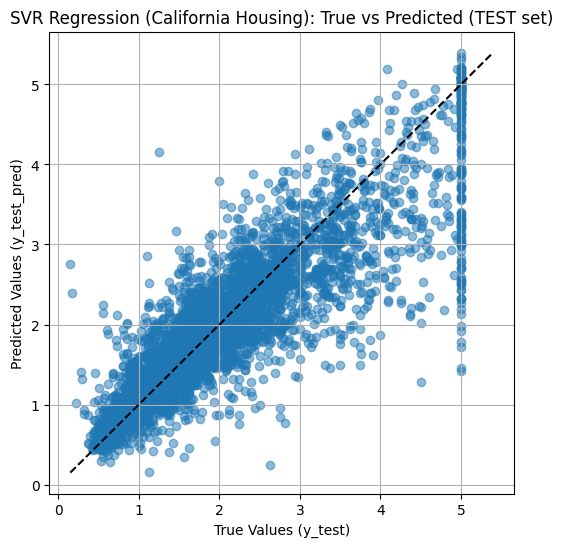

In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_test_pred, alpha=0.5)
plt.xlabel("True Values (y_test)")
plt.ylabel("Predicted Values (y_test_pred)")
plt.title("SVR Regression (California Housing): True vs Predicted (TEST set)")
min_val = min(y_test.min(), y_test_pred.min())
max_val = max(y_test.max(), y_test_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], "k--") # diagonal
plt.grid(True)
plt.show()
